# Free Energy - CV

In [ ]:
import torch
import torchvision.models as models
import numpy as np
import os
import matplotlib.pyplot as plt

## Save eigenvalues to dict for matrix

In [ ]:
def get_fc(model):
    if isinstance(model, models.vision_transformer.VisionTransformer):
        return model.heads[-1].weight.detach().cpu().flatten(1, -1)
    elif isinstance(model, models.swin_transformer.SwinTransformer):
        return model.head.weight.detach().cpu().flatten(1, -1)
    elif hasattr(model, 'fc'):
        return model.fc.weight.detach().cpu().flatten(1, -1)
    elif hasattr(model, 'classifier'):
        # if isinstance(model, models.vgg.VGG):
        #     return model.classifier[0].weight.detach().cpu().flatten(1, -1).T
        if hasattr(model.classifier, 'weight'):
            return model.classifier.weight.detach().cpu().flatten(1, -1)
        elif len(model.classifier) > 0 and hasattr(model.classifier[-1], 'weight'):
            return model.classifier[-1].weight.detach().cpu().flatten(1, -1)
        # Else take the final conv layer
        else:
            for p in model.classifier:
                if hasattr(p, 'weight'):
                    return p.weight.detach().cpu().flatten(1, -1)
        
    raise ValueError("Model does not have a recognized fully connected layer.")

In [ ]:
def get_deep_conv(model):
    # for name, param in reversed(list(model.named_parameters())):
    #     if 'conv' in name or 'Conv' in type(model).__name__:
    #         W = param.detach().cpu().flatten(1, -1)
    #         return W
    for name, param in list(model.named_parameters()):
        if param.requires_grad and len(param.shape) == 4:
            W = param.detach().cpu().flatten(1, -1)
            print(name)
            return W
    print("No convolutional layer found, returning None.")
    return None
   

In [ ]:
def save_eigenvalues_metrics(model_name, data_root = None, save_path = 'data/htmp/models', weight_type='final'):
    if data_root is not None:
        torch.hub.set_dir(data_root)
    os.makedirs(save_path, exist_ok=True)
    weight_enum = torch.hub.load("pytorch/vision", "get_model_weights", name=model_name)
    weights = weight_enum.DEFAULT
    metrics = weights.meta['_metrics']['ImageNet-1K']
    model = models.get_model(name=model_name, weights='DEFAULT').eval()
    if weight_type == 'final':
        W = get_fc(model)
    elif weight_type == 'deep_conv':
        if isinstance(model, models.vision_transformer.VisionTransformer):
            print(f"Model {model_name} is a transformer.")
            W = model.encoder.layers[-1].self_attention.out_proj.weight
        else:
            W = get_deep_conv(model)
            if W is None:
                print(f"No convolutional layer found for model {model_name}, skipping.")
                return
    if W.shape[0] > W.shape[1]:
        W = W.t()
    print(W.shape)
    e = torch.linalg.eigvalsh(W @ W.t())
    res_dict = {
        'model_name': model_name,
        'acc5': metrics['acc@5'],
        'acc1': metrics['acc@1'],
        'eigenvalues': e,
        'gamma': W.shape[0] / W.shape[1],
    }
    torch.save(res_dict, f'{save_path}/{model_name}_{weight_type}_eigs.pt')

In [ ]:
vgg_models = models.list_models(include='vgg*') # Dropout --> Terrible
mnasnet_models = models.list_models(include='mnasnet*') # Dropout, ---> Terrible
efficientnet_models = models.list_models(include='efficientnet*') # Dropout --> Terrible
mobilenet_models = models.list_models(include='mobilenet*') # Dropout ---> Good, wrong scale

swin_models = models.list_models(include='swin*')[3:] # transformer - bad
vit_models = models.list_models(include='vit*') # transformer - bad

alexnet_models = models.list_models(include='alexnet*') # Old --> Terrible
googlenet_models = models.list_models(include='googlenet*') # Old --> Terrible

resnet_models = models.list_models(include='resnet*') # No Dropout ---> Good
resnext_models = models.list_models(include='resnext*') # No Dropout ---> Good
convnext_models = models.list_models(include='convnext*') # No Dropout ---> Good
wide_resnet_models = models.list_models(include='wide_resnet*') # No Dropout ---> Good
regnet_models = models.list_models(include='regnet*') # No Dropout ---> Good
densenet_models = models.list_models(include='dense*') # No Dropout ---> Good
inception_models = models.list_models(include='inception*') # No Dropout ---> Good
shufflenet_models = models.list_models(include='shufflenet*') # No Dropout ---> Good

squeezenet_models = models.list_models(include='squeezenet*') # No Dropout ---> Good, wrong scale, maybe due to 'squeeze' architecture?


resnet_type_models = resnet_models + resnext_models + wide_resnet_models + regnet_models + convnext_models + densenet_models + inception_models + shufflenet_models
dropout_models = vgg_models + mnasnet_models + efficientnet_models + mobilenet_models
transformer_models = vit_models + swin_models
old_models = alexnet_models + googlenet_models

weird_models = squeezenet_models

vgg_models_bn = [model for model in vgg_models if 'bn' in model]
vgg_models_no_bn = [model for model in vgg_models if 'bn' not in model]

In [ ]:
for model_name in swin_models:
    print(f'Saving eigenvalues and metrics for {model_name}...')
    save_eigenvalues_metrics(model_name, save_path='data/htmp/models', weight_type='final')

Saving eigenvalues and metrics for swin_b...


Using cache found in R:\ntkuq_method-Q7521\saved_models\pytorch_vision_main


torch.Size([1000, 1024])
Saving eigenvalues and metrics for swin_s...


Using cache found in R:\ntkuq_method-Q7521\saved_models\pytorch_vision_main


torch.Size([768, 1000])
Saving eigenvalues and metrics for swin_t...


...

torch.Size([1000, 1024])
Saving eigenvalues and metrics for swin_v2_s...


Using cache found in R:\ntkuq_method-Q7521\saved_models\pytorch_vision_main


torch.Size([768, 1000])
Saving eigenvalues and metrics for swin_v2_t...


Using cache found in R:\ntkuq_method-Q7521\saved_models\pytorch_vision_main


torch.Size([768, 1000])


## Plot BFE-W vs. Test Acc

In [ ]:
def sort_architectures(model_names):
    arch_types = []
    for name in model_names:
        if 'resnet' in name:
            arch_types.append('ResNet')
        elif 'dense' in name.lower():
            arch_types.append('DenseNet')
        elif 'vit' in name.lower():
            arch_types.append('ViT*')
        elif 'swin' in name.lower():
            arch_types.append('Swin*')
        elif 'convnext' in name.lower():
            arch_types.append('ConvNeXt')
        elif 'regnet' in name.lower():
            arch_types.append('RegNet')
        elif 'efficientnet' in name.lower():
            arch_types.append('EfficientNet')
        elif 'resnext' in name.lower():
            arch_types.append('ResNeXt')
        elif 'inception' in name.lower():
            arch_types.append('Inception')
        elif 'shufflenet' in name.lower():
            arch_types.append('ShuffleNet')
        elif 'squeezenet' in name.lower():
            arch_types.append('SqueezeNet')
        elif 'mobilenet' in name.lower():
            arch_types.append('MobileNet')
        elif 'mnasnet' in name.lower():
            arch_types.append('MNASNet')
        elif 'vgg' in name.lower():
            arch_types.append('VGG')
        else:
            arch_types.append('Other')

    return arch_types

In [ ]:
def mean_bfe(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter))).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term + 1/2 * np.log(2 * np.pi / lam)
    return free_energy

In [ ]:
def mean_bfe_unnormalized(e, lam=1, n = 1000, jitter=1e-2):
    fro_norm = torch.sum(e + jitter).item() / n
    logdet_term = torch.sum(torch.log((e + jitter)/lam)).item() / n
    free_energy = lam/2 * fro_norm - 0.5 * logdet_term
    return free_energy

In [ ]:
def optim_lam(e, lam_min=1e-3, lam_max=1e3, num_lams=100, jitter=1e-2, n=1000):
    lams = np.logspace(np.log10(lam_min), np.log10(lam_max), num_lams)
    free_energies = [mean_bfe(e, lam, n, jitter=jitter) for lam in lams]
    optimal_lam = lams[np.argmin(free_energies)]
    optimal_free_energy = min(free_energies)
    return optimal_lam, optimal_free_energy

In [ ]:
import powerlaw
import weightwatcher.WW_powerlaw as WW_powerlaw
import weightwatcher.weightwatcher as ww_core

def patched_pl_fit(
    data=None,
    xmin=None,
    xmax=None,
    verbose=False,
    distribution=None,
    pl_package=None,
    **kwargs,
):
    return powerlaw.Fit(
        data,
        xmin=xmin,
        xmax=xmax,
        discrete=False,
        verbose=verbose,
    )

# patch both references
WW_powerlaw.pl_fit = patched_pl_fit
ww_core.pl_fit = patched_pl_fit

PyTorch is available but CUDA is not. Defaulting to SciPy for SVD
Import error , reetting to svd accurate methods


100%|██████████| 4/4 [01:25<00:00, 21.34s/it]


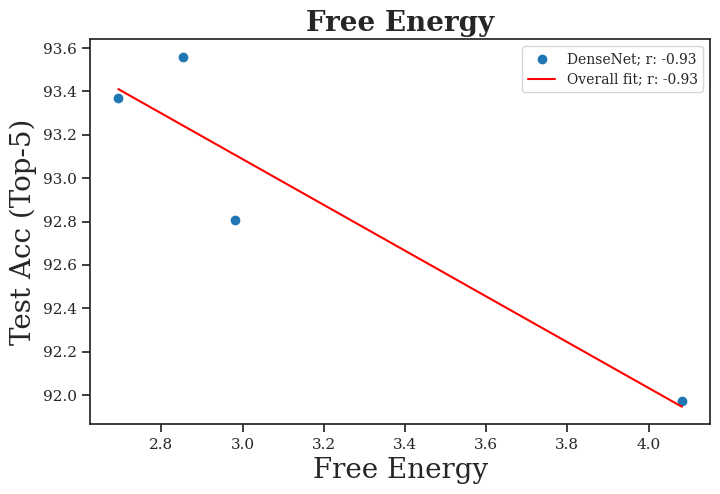

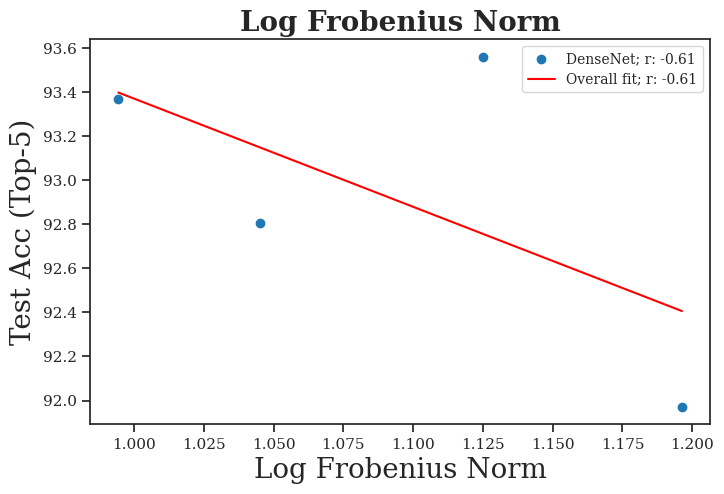

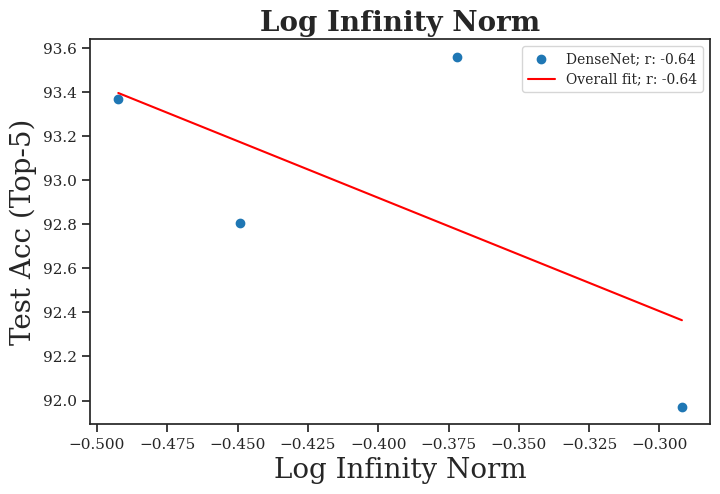

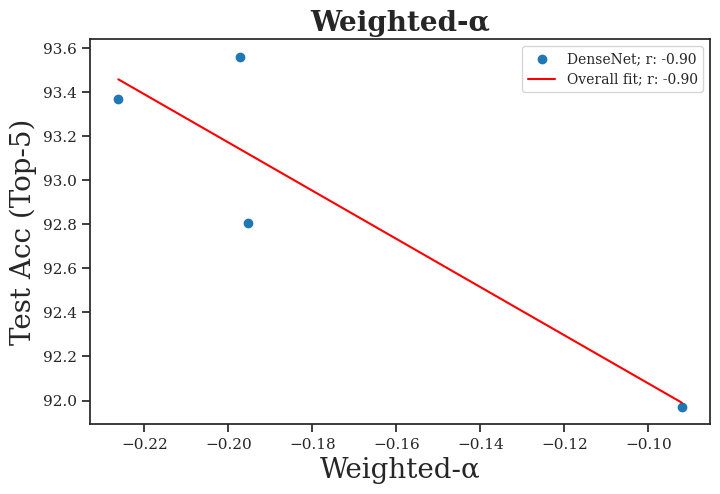

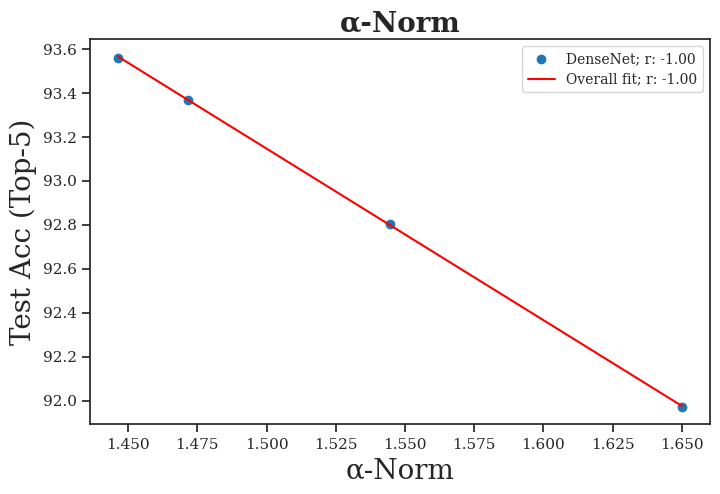

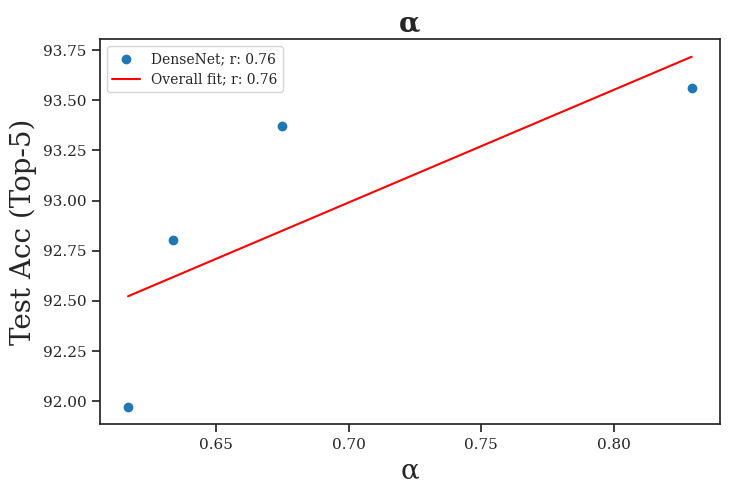

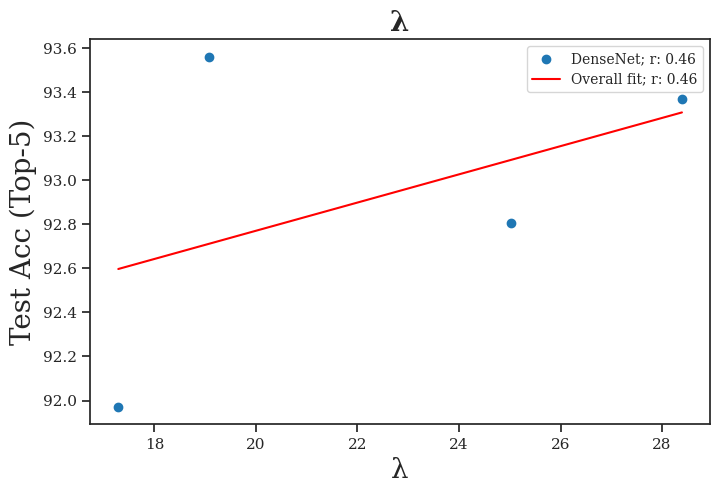

         model   acc@5   acc@1  Free Energy       min_eig  aspect_ratio  \
0  densenet121  91.972  74.434     4.082193 -2.797710e-06          1000   
1  densenet161  93.560  77.138     2.852745 -1.733160e-06          1000   
2  densenet169  92.806  75.600     2.980534 -1.763148e-06          1000   
3  densenet201  93.370  76.896     2.693720 -2.970740e-07          1000   

   Log Frobenius Norm  Log Infinity Norm  Weighted-α    α-Norm         α  \
0            1.196336          -0.292000   -0.092004  1.650080  0.616985   
1            1.125093          -0.371859   -0.197229  1.446435  0.829225   
2            1.045279          -0.449018   -0.195249  1.544538  0.633822   
3            0.994376          -0.492413   -0.226197  1.471639  0.675088   

           λ arch_type  
0  17.288436  DenseNet  
1  19.078160  DenseNet  
2  25.026131  DenseNet  
3  28.392122  DenseNet  


In [ ]:
import htmp.htmp as htmp; from importlib import reload; reload(htmp); import texplot; texplot.set_theme(); import json; import tqdm

fig_height = 6; fig_width = 8; font_size = 24; legend_size = 13; plot_ww = True
accs1 = []
accs5 = []

LOG_FROB_NORM = 'lognorm'
LOG_SPECTRAL_NORM = 'logspectralnorm'
ALPHA_WEIGHTED = 'alpha_weighted'
ALPHA_NORM = 'logpnorm'
DIR = 'old_ww_current_torchvision_all_default_spectralnorms'

# Metrics
metrics = {
    'Free Energy': [],
    'Log Frobenius Norm': [],
    'Log Infinity Norm': [],
    'Weighted-α': [],
    'α-Norm': [],
}

model_category = 'Old'  # 'ResNetType', 'Dropout', 'Transformer', 'Old'
if model_category == 'ResNetType':
    combined_models = resnet_type_models
elif model_category == 'Dropout':
    combined_models = dropout_models
elif model_category == 'Transformer':
    combined_models = transformer_models
elif model_category == 'Old':
    combined_models = old_models

f = '_eigs.pt'

min_eigs = []
aspect_ratios = []
for model_name in tqdm.tqdm(combined_models):
    res_dict = torch.load(f'results/htmp/models/{model_name}{f}')
    e = res_dict['eigenvalues']
    try:
        aspect_ratios.append(res_dict['gamma'])
    except:
        aspect_ratios.append(len(e))
    min_eigs.append(e.min().item())
    accs5.append(res_dict['acc5'])
    accs1.append(res_dict['acc1'])
    opt_lam, opt_free_energy = optim_lam(e, jitter=1e-4, n=1000, num_lams=1000)
    metrics['Free Energy'].append(opt_free_energy)
    
    if plot_ww:
        WW_res = json.load(open(f'{DIR}/summaries/{model_name}_summary.json', 'r'))
        lfn = WW_res[LOG_FROB_NORM]
        linf = WW_res[LOG_SPECTRAL_NORM]
        weight_alpha = WW_res[ALPHA_WEIGHTED]
        alpha_norm = WW_res[ALPHA_NORM]
        
    metrics['Log Frobenius Norm'].append(lfn)
    metrics['Log Infinity Norm'].append(linf)
    metrics['Weighted-α'].append(weight_alpha)
    metrics['α-Norm'].append(alpha_norm)

# Create dataframe of results with columns for model name, acc@5, acc@1, free energy, and min eigenvalue
import pandas as pd
df = pd.DataFrame({
    'model': combined_models,
    'acc@5': accs5,
    'acc@1': accs1,
    'Free Energy': metrics['Free Energy'],
    'min_eig': min_eigs,
    'aspect_ratio': aspect_ratios,
    'Log Frobenius Norm': metrics['Log Frobenius Norm'],
    'Log Infinity Norm': metrics['Log Infinity Norm'],
    'Weighted-α': metrics['Weighted-α'],
    'α-Norm': metrics['α-Norm'],
    'arch_type': sort_architectures(combined_models)
})


 # Sort models by architecture type, and colour by architecture type in the plot
df = df.sort_values('arch_type')
unique_arch_types = df['arch_type'].unique()
arch_type_to_color = {arch_type: plt.cm.tab10(i) for i, arch_type in enumerate(unique_arch_types)}

plot_metrics = metrics.keys() if plot_all_metrics else ['Free Energy']


for metric in plot_metrics:
    metric_df = df[[metric, 'acc@5', 'arch_type']].dropna().copy()
    metric_df[metric] = pd.to_numeric(metric_df[metric], errors='coerce')
    metric_df['acc@5'] = pd.to_numeric(metric_df['acc@5'], errors='coerce')
    metric_df = metric_df.dropna()

    plt.figure(figsize=(fig_width, fig_height))

    for arch_type in unique_arch_types:
        subset = metric_df[metric_df['arch_type'] == arch_type]
        if subset.empty:
            continue

        x_subset = subset[metric].to_numpy(dtype=float)
        y_subset = subset['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_subset) & np.isfinite(y_subset)
        x_subset = x_subset[finite_mask]
        y_subset = y_subset[finite_mask]

        label = arch_type
        if len(x_subset) >= 2 and np.unique(x_subset).size > 1:
            group_corr = np.corrcoef(x_subset, y_subset)[0, 1]
            group_fit = np.poly1d(np.polyfit(x_subset, y_subset, 1))
            group_rmse = np.sqrt(np.mean((y_subset - group_fit(x_subset)) ** 2))
            label = f'{arch_type}; r: {group_corr:.2f}'

        plt.scatter(
            x_subset,
            y_subset,
            marker='o',
            label=label,
            color=arch_type_to_color[arch_type],
        )

    if len(metric_df) >= 2 and metric_df[metric].nunique() > 1:
        # Only include finite values for correlation and fitting
        x_vals = metric_df[metric].to_numpy(dtype=float)
        y_vals = metric_df['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[finite_mask]
        y_vals = y_vals[finite_mask]
        m, b = np.polyfit(x_vals, y_vals, 1)
        fitted = m * x_vals + b
        overall_corr = np.corrcoef(x_vals, y_vals)[0, 1]
        overall_rmse = np.sqrt(np.mean((y_vals - fitted) ** 2))
        x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)
        plt.plot(
            x_plot,
            m * x_plot + b,
            color='red',
            label=f'Overall fit; r: {overall_corr:.2f}',
        )
    title_f = f'{metric}' if plot_all_metrics else 'CV'
    plt.title(title_f, fontsize=font_size, fontweight='bold')
    plt.xlabel(metric, fontsize=font_size)
    plt.ylabel('Test Acc (Top-5)', fontsize=font_size)
    plt.legend(fontsize=legend_size, ncol=2, loc='lower left', frameon=True)
    
    f_ww = 'all_weights' if weight_watchers_all_weights else 'final_layer_weights'

    save_f = f'free_energy_vs_acc_cv_{model_category}.pdf' if not plot_all_metrics else f'{metric}_{f_ww}_vs_acc5_{model_category}.pdf'
    plt.savefig('figures/paper/' + save_f, bbox_inches='tight', format='pdf')
    plt.show()

print(df)

### Legacy

In [ ]:
import re
from collections import OrderedDict

def fix_old_densenet_state_dict_keys(state_dict):
    """
    Converts old torchvision DenseNet checkpoint keys:
        norm.1.weight -> norm1.weight
        conv.1.weight -> conv1.weight
        norm.2.weight -> norm2.weight
        conv.2.weight -> conv2.weight
    """
    pattern = re.compile(
        r"^(.*denselayer\d+\.)(norm|relu|conv)\.([12])\.(.*)$"
    )

    new_state_dict = OrderedDict()

    for key, value in state_dict.items():
        new_key = pattern.sub(r"\1\2\3.\4", key)
        new_state_dict[new_key] = value

    return new_state_dict

In [ ]:
def final_weights_state_dict(model_name, state_dict):
    if model_name.startswith('resnet'):
        W = state_dict['fc.weight'].cpu().detach()
    elif model_name.startswith('vgg'):
        W = state_dict['classifier.6.weight'].cpu().detach()
    elif model_name.startswith('densenet'):
        W = state_dict['classifier.weight'].cpu().detach()
    return W

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

urls = {
    "resnet18": "https://download.pytorch.org/models/resnet18-5c106cde.pth",
    "resnet34": "https://download.pytorch.org/models/resnet34-333f7ec4.pth",
    "resnet50": "https://download.pytorch.org/models/resnet50-19c8e357.pth",
    "resnet101": "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth",
    "resnet152": "https://download.pytorch.org/models/resnet152-b121ed2d.pth",

    "vgg11": "https://download.pytorch.org/models/vgg11-bbd30ac9.pth",
    "vgg11_bn": "https://download.pytorch.org/models/vgg11_bn-6002323d.pth",
    "vgg13": "https://download.pytorch.org/models/vgg13-c768596a.pth",
    "vgg13_bn": "https://download.pytorch.org/models/vgg13_bn-abd245e5.pth",
    "vgg16": "https://download.pytorch.org/models/vgg16-397923af.pth",
    "vgg16_bn": "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth",
    "vgg19": "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth",
    "vgg19_bn": "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth",

    "densenet121": "https://download.pytorch.org/models/densenet121-a639ec97.pth",
    "densenet161": "https://download.pytorch.org/models/densenet161-8d451a50.pth",
    "densenet169": "https://download.pytorch.org/models/densenet169-b2777c0a.pth",
    "densenet201": "https://download.pytorch.org/models/densenet201-c1103571.pth",
}

out = Path("torchvision_0_4_2_checkpoints")
out.mkdir(exist_ok=True)

for name, url in urls.items():
    fname = url.split("/")[-1]
    path = out / fname
    if not path.exists():
        print("Downloading", fname)
        urlretrieve(url, path)
    else:
        print("Already exists", fname)

In [ ]:
import texplot; texplot.set_theme(); import json; import tqdm

fig_height = 6; fig_width = 8; font_size = 24; legend_size = 13; plot_ww = True
accs1 = []
accs5 = []

LOG_FROB_NORM = 'lognorm'
LOG_SPECTRAL_NORM = 'logspectralnorm'
ALPHA_WEIGHTED = 'alpha_weighted'
ALPHA_NORM = 'logpnorm'
DIR = 'ww_trends_2020_repo_v1_summaries'
folder = 'torchvision_0_4_2_checkpoints'

# Metrics
metrics = {
    'Free Energy': [],
    'Log Frobenius Norm': [],
    'Log Infinity Norm': [],
    'Weighted-α': [],
    'α-Norm': [],
    'α': [],
}

model_category = 'Legacy'  # 'ResNetType', 'Dropout', 'Transformer', 'Old', 'Legacy'
if model_category == 'ResNetType':
    combined_models = resnet_type_models
elif model_category == 'Dropout':
    combined_models = dropout_models
elif model_category == 'Transformer':
    combined_models = transformer_models
elif model_category == 'Old':
    combined_models = old_models
elif model_category == 'Legacy':
    combined_models = resnet_models + vgg_models + densenet_models

min_eigs = []
aspect_ratios = []
for model_name in tqdm.tqdm(combined_models):
    model = models.get_model(name=model_name, weights=None)
    state_dict = torch.load(f'{folder}/{urls[model_name].split("/")[-1]}', map_location="cpu", weights_only=False)
    if 'densenet' in model_name:
        state_dict = fix_old_densenet_state_dict_keys(state_dict)
    model.load_state_dict(state_dict)

    W = final_weights_state_dict(model_name, state_dict)
    if W.shape[0] != 1000:
        W = W.T
    if W.shape[0] == 1000:
        e = torch.linalg.eigvalsh(W @ W.t())

    aspect_ratios.append(W.shape[0] / W.shape[1])
    min_eigs.append(e.min().item())

    WW_res = json.load(open(f'{DIR}/summaries/{model_name}_v1_summary.json', 'r'))
    
    if plot_ww:
        
        lfn = WW_res[LOG_FROB_NORM]
        linf = WW_res[LOG_SPECTRAL_NORM]
        weight_alpha = WW_res[ALPHA_WEIGHTED]
        alpha_norm = WW_res[ALPHA_NORM]

    accs5.append(WW_res['top5_acc'])
    accs1.append(WW_res['top1_acc'])
    opt_lam, opt_free_energy = optim_lam(e, jitter=1e-4, n=1000, num_lams=1000)
    metrics['Free Energy'].append(opt_free_energy)

    metrics['Log Frobenius Norm'].append(lfn)
    metrics['Log Infinity Norm'].append(linf)
    metrics['Weighted-α'].append(weight_alpha)
    metrics['α-Norm'].append(alpha_norm)
    # metrics['λ'].append(lambda_ww)

# Create dataframe of results with columns for model name, acc@5, acc@1, free energy, and min eigenvalue
import pandas as pd
df = pd.DataFrame({
    'model': combined_models,
    'acc@5': accs5,
    'acc@1': accs1,
    'Free Energy': metrics['Free Energy'],
    'min_eig': min_eigs,
    'aspect_ratio': aspect_ratios,
    'Log Frobenius Norm': metrics['Log Frobenius Norm'],
    'Log Infinity Norm': metrics['Log Infinity Norm'],
    'Weighted-α': metrics['Weighted-α'],
    'α-Norm': metrics['α-Norm'],
    'α': metrics['α'],
    # 'λ': metrics['λ'],
    'arch_type': sort_architectures(combined_models)
})


 # Sort models by architecture type, and colour by architecture type in the plot
df = df.sort_values('arch_type')
unique_arch_types = df['arch_type'].unique()
arch_type_to_color = {arch_type: plt.cm.tab10(i) for i, arch_type in enumerate(unique_arch_types)}

plot_metrics = metrics.keys() if plot_ww else ['Free Energy']


for metric in plot_metrics:
    metric_df = df[[metric, 'acc@5', 'arch_type']].dropna().copy()
    metric_df[metric] = pd.to_numeric(metric_df[metric], errors='coerce')
    metric_df['acc@5'] = pd.to_numeric(metric_df['acc@5'], errors='coerce')
    metric_df = metric_df.dropna()

    plt.figure(figsize=(fig_width, fig_height))

    for arch_type in unique_arch_types:
        subset = metric_df[metric_df['arch_type'] == arch_type]
        if subset.empty:
            continue

        x_subset = subset[metric].to_numpy(dtype=float)
        y_subset = subset['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_subset) & np.isfinite(y_subset)
        x_subset = x_subset[finite_mask]
        y_subset = y_subset[finite_mask]

        label = arch_type
        if len(x_subset) >= 2 and np.unique(x_subset).size > 1:
            group_corr = np.corrcoef(x_subset, y_subset)[0, 1]
            group_fit = np.poly1d(np.polyfit(x_subset, y_subset, 1))
            group_rmse = np.sqrt(np.mean((y_subset - group_fit(x_subset)) ** 2))
            label = f'{arch_type}; r: {group_corr:.2f}'

        plt.scatter(
            x_subset,
            y_subset,
            marker='o',
            label=label,
            color=arch_type_to_color[arch_type],
        )

    if len(metric_df) >= 2 and metric_df[metric].nunique() > 1:
        # Only include finite values for correlation and fitting
        x_vals = metric_df[metric].to_numpy(dtype=float)
        y_vals = metric_df['acc@5'].to_numpy(dtype=float)
        finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[finite_mask]
        y_vals = y_vals[finite_mask]
        m, b = np.polyfit(x_vals, y_vals, 1)
        fitted = m * x_vals + b
        overall_corr = np.corrcoef(x_vals, y_vals)[0, 1]
        overall_rmse = np.sqrt(np.mean((y_vals - fitted) ** 2))
        x_plot = np.linspace(x_vals.min(), x_vals.max(), 200)
        plt.plot(
            x_plot,
            m * x_plot + b,
            color='red',
            label=f'Overall fit; r: {overall_corr:.2f}',
        )
    title_f = f'{metric}' if plot_ww else 'CV'
    plt.title(title_f, fontsize=font_size, fontweight='bold')
    plt.xlabel(metric, fontsize=font_size)
    plt.ylabel('Test Acc (Top-5)', fontsize=font_size)
    plt.legend(fontsize=legend_size, ncol=2, loc='lower left', frameon=True)
    
    f_ww = 'all_weights'

    save_f = f'free_energy_vs_acc_cv_{model_category}.pdf' if not plot_ww else f'{metric}_{f_ww}_vs_acc5_{model_category}.pdf'
    plt.savefig('figures/paper/' + save_f, bbox_inches='tight', format='pdf')
    plt.show()

print(df)

# HTMP

### Load ESDFit

In [ ]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)

# Load fits
fit = esdfit.ESDFit(model='resnet34', dataset='cifar10', kernel='weight', batch_size=100, subsample=False, file_dir = 'data/htmp/epoch')
fit.load_htmp_fit()

True

### Fit HTMP

In [33]:
fit.fit_htmp(search_method='grid', 
             shared_beta_grid=False, 
             beta_from_tau=True,
             c = 0.8,
             kappa_min=0.01, 
             kappa_max=1, 
             num_kappas=20, 
             kappa_log_scale=False,
             n_eval=200, 
             beta_min=1, 
             beta_max = 40, 
             num_betas = 40, 
             tau_min=0,
             tau_max=0,
             num_taus=1,
             epochs_list=range(40, 200, 5),
             moment_penalty_weight=1,
             verbose=True,
             extra_verbose=True,
             shared_tau_grid=False,
             stieltjes=False,
             vectorized_grid=True,
             save_fit=True)

Loading eigenvalues...
Fitting HTMP parameters for 32 epochs using grid search...
Beta grid arguments are ignored: beta is set per epoch to 0.8 / tau.
Best grid point: kappa=0.3226, beta=3.158, distance=0.191388
Fitting HTMP for Epoch: 40, κ*: 0.323, β*: 3.158, τ*: 0.253, ||.||ₚ*: 0.191
Best grid point: kappa=0.3226, beta=3.439, distance=0.202248
Fitting HTMP for Epoch: 45, κ*: 0.323, β*: 3.439, τ*: 0.233, ||.||ₚ*: 0.202
Best grid point: kappa=0.3226, beta=3.729, distance=0.206475
Fitting HTMP for Epoch: 50, κ*: 0.323, β*: 3.729, τ*: 0.215, ||.||ₚ*: 0.206
Best grid point: kappa=0.3747, beta=4.079, distance=0.214948
Fitting HTMP for Epoch: 55, κ*: 0.375, β*: 4.079, τ*: 0.196, ||.||ₚ*: 0.215
Best grid point: kappa=0.3747, beta=4.4, distance=0.225361
Fitting HTMP for Epoch: 60, κ*: 0.375, β*: 4.400, τ*: 0.182, ||.||ₚ*: 0.225
Best grid point: kappa=0.3747, beta=4.804, distance=0.231568
Fitting HTMP for Epoch: 65, κ*: 0.375, β*: 4.804, τ*: 0.167, ||.||ₚ*: 0.232
Best grid point: kappa=0.3747

### Plot ESD / HTMP

5it [00:00, 11.05it/s]


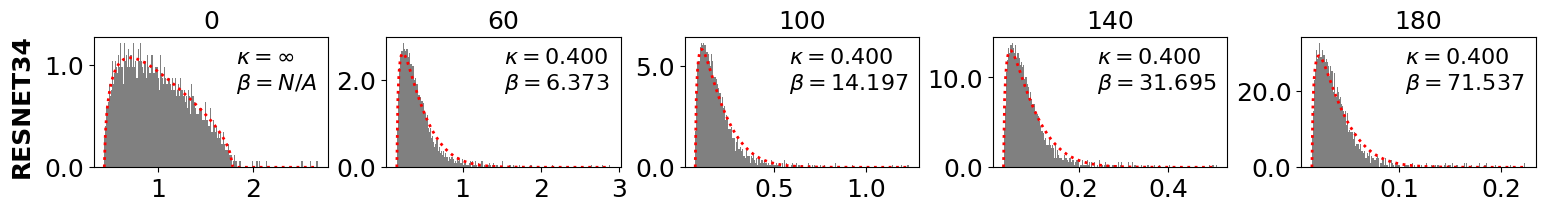

In [26]:
# Plot ESD fits
fit.plot_esd(epochs_list=[0, 60, 100, 140, 180], 
             log_bins=False, 
             n_bins=200, 
             log_y=False, 
             title=True, 
             fontsize=18, 
             plot_power=False, 
             plot_htmp=True, 
             fig_width=15,
             fig_height_per_row=2)

### Fit by-hand

1it [00:00,  8.79it/s]


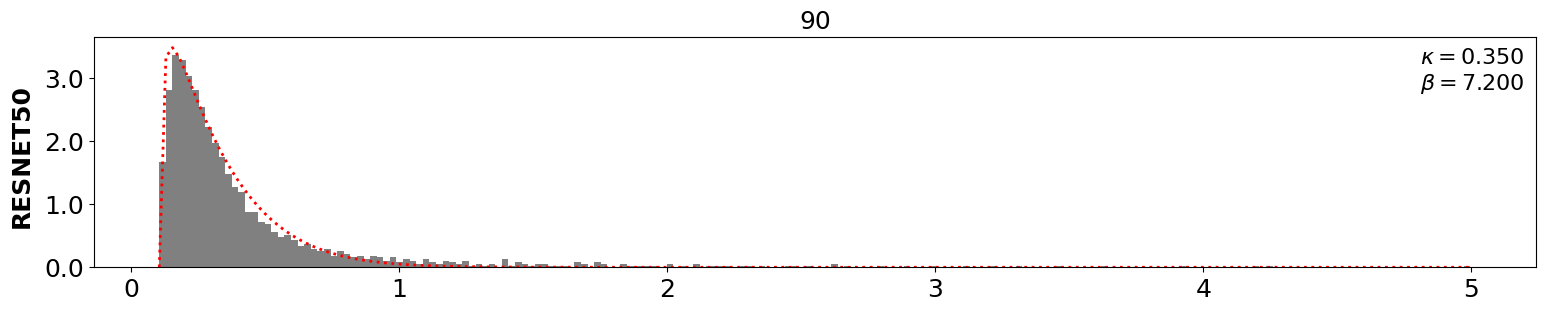

In [5]:
fit.kappa_opt[90] = 0.35
fit.beta_opt[90] = 7.2
fit.plot_esd(epochs_list=[90], log_bins=False, n_bins=200, log_y=False, title=True, fontsize=18, plot_power=False, plot_htmp=True)

In [8]:
fit.save_htmp_fit()

'results/htmp/fits\\resnet50_cifar10_weight_b100_fit.pt'

### Ratio vs. Epochs

Skipping epochs for κ/β plot: 0 (missing kappa/beta), 5 (missing kappa/beta), 10 (missing kappa/beta), 15 (missing kappa/beta), 20 (missing kappa/beta), 25 (missing kappa/beta), 30 (missing kappa/beta), 35 (missing kappa/beta)


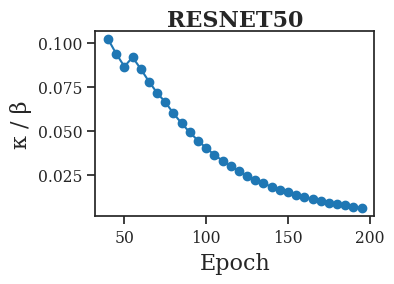

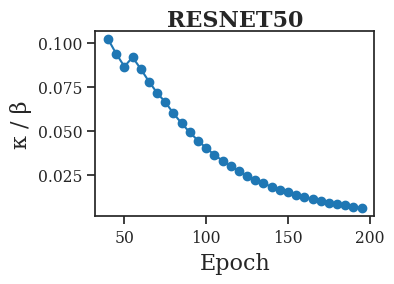

In [45]:
fig, ax = fit.plot_kappa_beta_ratio_vs_epoch(
    start_index=0,
    title=True,
    fig_width=4,
    fig_height=3,
    fontsize=16,
    texplot_enabled=True,
    show_fig=True,
)

### Free Energy vs Test

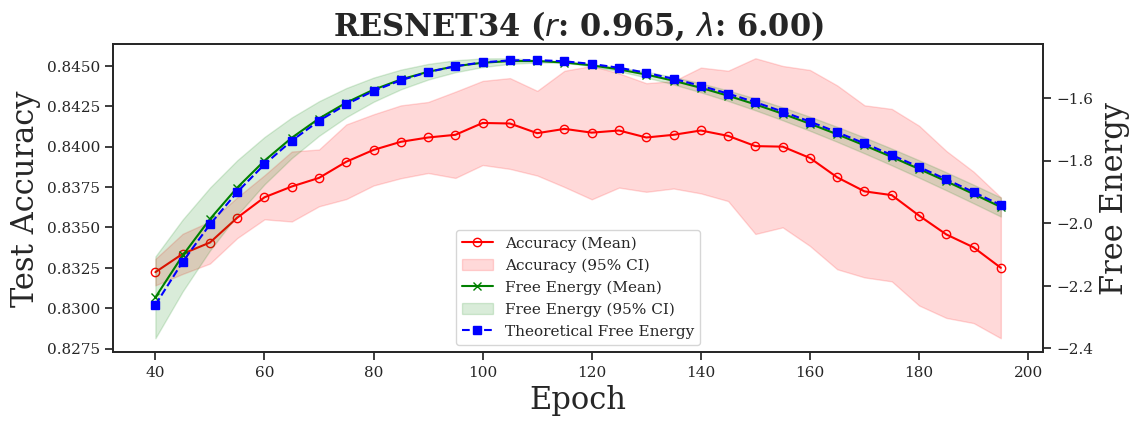

Correlation between Test Accuracy and -Free Energy: 0.965
Maximum Test Accuracy: 0.841 at Epoch=100, Free Energy=-1.48732


In [20]:
lambas = {
    'resnet18': 3,
    'resnet34': 6,
    'resnet50': 6,
}
lam = lambas[fit.model]
start_index = 8
x_var = 'epochs'

if x_var == 'kappa_beta_ratio':
    # Compute optimal kappa/beta ratio
    kappa = np.array([fit.kappa_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    c = np.array([fit.beta_opt[epoch] * fit.tau_opt[epoch] for epoch in fit.epoch_list[start_index:]]).mean()
    gamma = fit._get_gamma()

    opt_ratio = 2*gamma*kappa / (lam *(kappa + 2*gamma*c))
    print(f'Optimal kappa/beta ratio: {opt_ratio}')
else:
    opt_ratio = None


# Plot free energy fits
fit.compute_free_energy(lam=lam, tau=0, weight_inverse=True)

fit.plot_test_vs_free(variable=x_var, 
                      neg_free='True', 
                      start_index =start_index, 
                      plot_theoretical_free=True, 
                      single_plot=True, 
                      fig_height=4, 
                      fig_width=12,
                      fontsize=22, 
                      texplot_enabled=True,
                      optimal_ratio=opt_ratio,
                      marker_size=250,
                      tight_layout=False)

### Trace and Log Det vs Var

Log-Det at epoch 8: empirical=0.642
Min free energy epoch: 135, min empirical free energy: 1.29


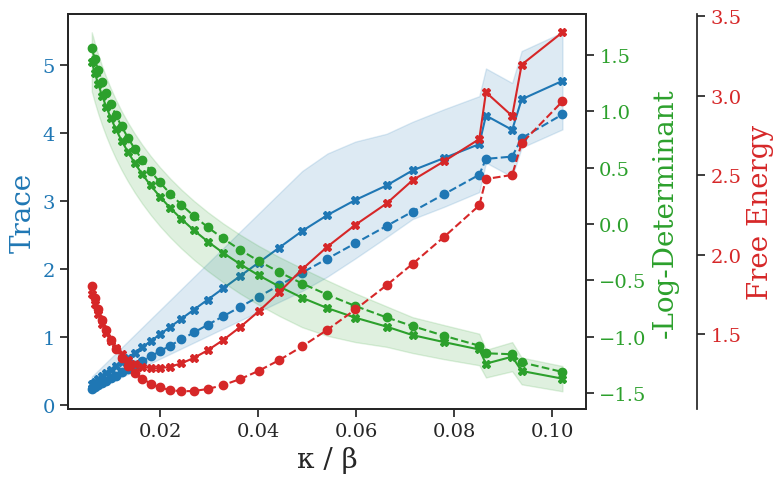

In [46]:
trace_variable = 'kappa_beta_ratio'  # 'epochs', 'kappa', 'beta', or 'kappa_beta_ratio'
start_index = 8
fit.compute_free_energy(lam=6, tau=0, weight_inverse=True)
fit.plot_trace_and_log_det(variable=trace_variable, 
                           plot_theoretical=True, 
                           start_index=start_index, 
                           plot_sum=True, 
                           fig_height=5, 
                           fig_width=8, 
                           fontsize=20, 
                           texplot_enabled=True,
                           legend_on=False,
                           title=False)

### Plot kappa/beta vs epochs for all resnets

Plotting κ/β ratio vs. epoch on provided axes.
c = 1.45
Plotting κ/β ratio vs. epoch on provided axes.
c = 1.0
Plotting κ/β ratio vs. epoch on provided axes.
c = 0.8


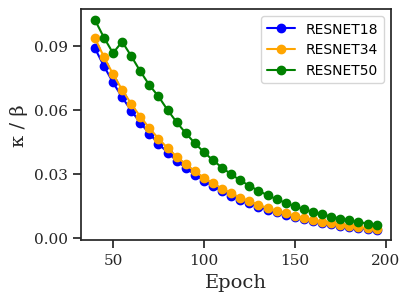

In [ ]:
import esdfit as esdfit
import numpy as np
from importlib import reload; reload(esdfit)
import matplotlib.pyplot as plt
import texplot
texplot.set_theme()
models = ['resnet18', 'resnet34', 'resnet50']
colors = ['blue', 'orange', 'green']
fig, ax = plt.subplots(figsize=(4, 3))

for model, color in zip(models, colors):
    # Load fits
    fit = esdfit.ESDFit(model=model, dataset='cifar10', kernel='weight', batch_size=100, subsample=False, file_dir = 'data/htmp/epoch')
    fit.load_htmp_fit()
    ax = fit.plot_kappa_beta_ratio_vs_epoch(
        start_index=8,
        title=False,
        fontsize=14,
        texplot_enabled=True,
        show_fig=False,
        save_fig=False,
        axes=ax,
        color_plot=color
    )
    print(f'c = {fit.beta_opt[fit.epoch_list[8]] * fit.tau_opt[fit.epoch_list[8]]}')
# ax.set_title(r'$\kappa/\beta$ Ratio vs. Epoch', fontsize=16, fontweight='bold')

# Have fewer number of ticks on both axes
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

ax.legend()
# fig.tight_layout()
fig.savefig('figures/paper/resnet_kappa_beta_ratio.pdf', bbox_inches='tight', format='pdf')
plt.show()    